<a href="https://colab.research.google.com/github/chetan630/HQCRF-Implementation_Capstone/blob/main/scenario-2-jamming-attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --force-reinstall qiskit==2.2.3 qiskit-ibm-runtime==0.44.0  numpy==2.3.2 scipy==1.16.1 matplotlib==3.10.6 networkx==3.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 45.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 188.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 63.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 163.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 46.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 65.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.

In [ ]:
%%file user_input.py
import random
def get_user_input():
    default_config = {
        "width": 100,
        "height": 100,
        "nodes": 500,
        "steps": 21,
        "range": 45,
        "user_step": 7
    }

    num_nodes = default_config["nodes"]
    default_config["source"] = random.randint(0, num_nodes - 1)
    default_config["destination"] = random.randint(0, num_nodes - 1)

    while default_config["source"] == default_config["destination"]:
        default_config["destination"] = random.randint(0, num_nodes - 1)

    return (
        default_config["width"],
        default_config["height"],
        default_config["nodes"],
        default_config["steps"],
        default_config["range"],
        default_config["source"],
        default_config["destination"],
        default_config["user_step"]
    )

Writing user_input.py


In [ ]:
%%file mobility_simulator.py
import numpy as np

class Node:
    def __init__(self, node_id, area_size, num_nodes):
        self.id = node_id
        self.area_size = area_size

        self.trust = np.round(np.random.uniform(0.6, 1.0), 2)
        self.energy = np.random.uniform(70, 100)
        self.jammed = False

        x = np.random.uniform(0, area_size)
        y = np.random.uniform(0, area_size)
        self.position = np.array([x, y])
        self.speed = np.random.uniform(0.9, 2)
        self.destination = np.random.rand(2) * self.area_size

    def update_position(self, dt, nodes, comm_range):

        direction = self.destination - self.position
        distance = np.linalg.norm(direction)

        if distance < 1:
            self.destination = np.random.rand(2) * self.area_size
            return

        move_vector = (direction / distance) * self.speed * dt
        self.position += move_vector
        self.position = np.clip(self.position, 0, self.area_size)

        self.energy = max(self.energy - np.random.uniform(0.2, 0.5), 0)

        neighbors = [n for n in nodes if n.id != self.id and np.linalg.norm(self.position - n.position) <= comm_range]
        if not neighbors or self.jammed:
            self.trust = max(self.trust - 0.01, 0.3)
        else:
            self.trust = min(self.trust + 0.005, 1.0)

def initialize_nodes(num_nodes, area_size):
    """Create a list of movable nodes including a command node."""
    return [Node(i, area_size, num_nodes) for i in range(num_nodes)]

def move_nodes(nodes, dt=1.0, comm_range=45):
    """Update all node positions and return updated position dictionary."""
    for node in nodes:
        node.update_position(dt, nodes, comm_range)
    return {node.id: node.position for node in nodes}

Writing mobility_simulator.py


In [ ]:
%%file jammer_logic.py
import random

def is_node_blocked(i, j, jammers, step):
    for jammer in jammers:
        if jammer['location'] == 'node' and (i == jammer['target'] or j == jammer['target']):
            if jammer['type'] == 'constant':
                return True
            elif jammer['type'] == 'random':
                return random.random() < 0.5
            elif jammer['type'] == 'reactive':
                return True
    return False

Writing jammer_logic.py


In [ ]:
%%file jammer_config.py
import random

def init_jammers(positions, G, max_jammers=3):
    jammer_types = ['constant', 'random', 'reactive']
    num_jammers = random.randint(1, max_jammers)
    jammer_info = []

    node_ids = list(range(0, len(positions) - 1))

    for _ in range(num_jammers):
        if node_ids:
            target = random.choice(node_ids)
            node_ids.remove(target)
            j_type = random.choice(jammer_types)
            radius = random.randint(1, 5)
            jammer_info.append({'type': j_type, 'location': 'node', 'target': target, 'radius': radius})

    return jammer_info

Overwriting jammer_config.py


In [ ]:
%%file grover_router.py
import networkx as nx
import numpy as np
from math import ceil, log2
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.circuit.library import GroverOperator
from collections import Counter
import time
import random
import concurrent.futures

# ==============================
#  CONSTANTS
# ==============================
TRUST_THRESHOLD = 0.5
ENERGY_CRITICAL = 20.0
LINK_STABILITY_WEIGHT = 0.75

PENALTY_LOW_TRUST = 30
PENALTY_CRITICAL_ENERGY = 50
PENALTY_JAMMED_NODE = 0
PENALTY_HOP_COUNT = 10

MAX_QUBITS = 6
MAX_CHUNK_SIZE = 2 ** MAX_QUBITS
ENABLE_FALLBACK = True


MAX_BEAM_WIDTH = 14
MAX_RELAXATION_ATTEMPTS = 3
RELAX_DIRECTION_FACTOR = 1.075

HIGH_STABILITY_THRESHOLD = 0.17
LOW_STABILITY_THRESHOLD = 0.04
STABILITY_PENALTY_WEIGHT = 36
ENABLE_DUAL_BACKEND_PARALLEL = True

MIN_STABILITY_THRESHOLD = LOW_STABILITY_THRESHOLD
PATH_RELIABILITY_WEIGHT = 15.0

# =====================================================
#               CANDIDATE PATH GENERATION (CLASSICAL HARD FILTERING)
# =====================================================
def _do_path_generation_core(G, source, dest, current_beam_width):
    if not G.has_node(source) or not G.has_node(dest):
        return []

    def euclidean_distance(pos1, pos2):
        return np.linalg.norm(pos1 - pos2)

    if 'pos' not in G.nodes[source] or 'pos' not in G.nodes[dest]:
        return []

    dest_pos = np.array(G.nodes[dest]['pos'])

    paths = set()
    stack = [(source, [source], np.array(G.nodes[source]['pos']))]

    while stack:
        current_node, current_path, current_node_pos = stack.pop()
        if current_node == dest:
            paths.add(tuple(current_path))
            continue

        distance_current_to_dest = euclidean_distance(current_node_pos, dest_pos)

        promising_neighbors = []
        for neighbor in G.neighbors(current_node):
            if neighbor not in current_path:
                if G.nodes[neighbor]['energy'] <= 0:
                    continue
                # if G.nodes[neighbor]['jammed']:
                #     continue

                neighbor_pos = np.array(G.nodes[neighbor]['pos'])
                distance_neighbor_to_dest = euclidean_distance(neighbor_pos, dest_pos)

                if distance_neighbor_to_dest <= distance_current_to_dest * RELAX_DIRECTION_FACTOR:
                    promising_neighbors.append((neighbor, neighbor_pos, distance_neighbor_to_dest))

        promising_neighbors.sort(key=lambda x: x[2])
        selected_neighbors = promising_neighbors[:current_beam_width]

        for neighbor, neighbor_pos, _ in selected_neighbors:
            new_path = current_path + [neighbor]
            stack.append((neighbor, new_path, neighbor_pos))

    return [list(p) for p in paths]

def generate_candidate_paths(G, source, dest):
    if not G.has_node(source) or not G.has_node(dest):
        print(f"[DEBUG: Reduction] Source ({source}) or Destination ({dest}) node not in graph. Returning empty paths.")
        return []

    def euclidean_distance(pos1, pos2):
        return np.linalg.norm(pos1 - pos2)

    if 'pos' not in G.nodes[source] or 'pos' not in G.nodes[dest]:
        print("[ERROR] Source or Destination node missing 'pos' attribute. Cannot apply directional pathfinding.")
        return []

    num_nodes = G.number_of_nodes()
    print(f"[DEBUG: Reduction] Starting path generation for {num_nodes} nodes.")

    initial_beam_width = 6

    current_beam_width = initial_beam_width

    paths_found_count = 0
    relaxation_attempts_performed = 0

    all_candidate_paths_raw = _do_path_generation_core(G, source, dest, current_beam_width)
    paths_found_count = len(all_candidate_paths_raw)
    print(f"[DEBUG] Initial attempt: BEAM_WIDTH = {current_beam_width}. Found {paths_found_count} paths.")

    if paths_found_count == 0:
        print("[DEBUG] No paths found. Activating adaptive relaxation (beam width only).")
        for attempt in range(MAX_RELAXATION_ATTEMPTS):
            relaxation_attempts_performed += 1

            if current_beam_width < MAX_BEAM_WIDTH:
                current_beam_width = min(current_beam_width + 1, MAX_BEAM_WIDTH)

            print(f"[DEBUG] Relaxation Attempt {relaxation_attempts_performed}: BEAM_WIDTH = {current_beam_width}.")
            all_candidate_paths_raw = _do_path_generation_core(G, source, dest, current_beam_width)
            paths_found_count = len(all_candidate_paths_raw)

            if paths_found_count > 0:
                print(f"[DEBUG] Relaxation successful. Paths found: {paths_found_count}.")
                break
        else:
            print("[ERROR] Adaptive hard filtering exhausted. No feasible paths found after max attempts.")
            return []

    print(f"[DEBUG] Final Beam Width (K): {current_beam_width}")
    print(f"[DEBUG] Generated {paths_found_count} directional paths with beam width control, dynamic hop pruning, and shortest path refinement.")
    print(f"[DEBUG] Number of relaxation attempts performed: {relaxation_attempts_performed}")
    global_initial_beam_width_used = initial_beam_width
    global_final_beam_width_used = current_beam_width
    global_relaxation_attempts_performed = relaxation_attempts_performed

    return all_candidate_paths_raw


# =====================================================
#                COST FUNCTION (FOR GROVER STAGE)
# =====================================================
def cost_function_with_penalties(path, G, nodes_by_id):
    if len(path) < 2:
        print(f"[DEBUG: Cost Function] Path {path} has length < 2. Returning inf.")
        return {"edge_costs": float('inf'), "trust_penalties": 0, "energy_penalties": 0,
                "jam_penalties": 0, "hop_penalties": 0, "stability_penalties": 0, "reliability_penalties": 0, "total": float('inf')}

    edge_costs = 0
    trust_penalties = 0
    energy_penalties = 0
    jam_penalties = 0
    stability_penalties = 0
    path_reliability = 1.0

    for idx, node_id in enumerate(path):
        if node_id not in nodes_by_id:
            print(f"[DEBUG: Cost Function] Path {path} contains node {node_id} not in nodes_by_id. Returning inf.")
            return {"total": float('inf')}
        node = nodes_by_id[node_id]

        if node.energy < ENERGY_CRITICAL:
            energy_penalties += PENALTY_CRITICAL_ENERGY
        if node.trust < TRUST_THRESHOLD:
            trust_penalties += PENALTY_LOW_TRUST
        if node.jammed:
            jam_penalties += PENALTY_JAMMED_NODE

    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        if not G.has_edge(u, v):
            print(f"[DEBUG: Cost Function] Path {path} edge ({u}, {v}) not found in G. Available edges for {u}: {[edge for edge in G.edges(u)]}. Returning inf.")
            return {"total": float('inf')}

        w = G[u][v]["weight"]
        link_stability = G[u][v].get("stability", 1.0)

        if link_stability <= MIN_STABILITY_THRESHOLD:
            print(f"[DEBUG: Cost Function] Path {path} discarded due to link ({u}, {v}) stability {link_stability:.2f} below threshold {MIN_STABILITY_THRESHOLD}.")
            return {"total": float('inf')}

        current_stability_penalty = LINK_STABILITY_WEIGHT * ((1 - link_stability) ** 2)
        edge_costs += w + current_stability_penalty
        stability_penalties += current_stability_penalty

        path_reliability *= link_stability

    hop_penalties = (len(path)-1) * PENALTY_HOP_COUNT

    reliability_penalty_total = PATH_RELIABILITY_WEIGHT * (1 - path_reliability)

    total = edge_costs + trust_penalties + energy_penalties + jam_penalties + hop_penalties + reliability_penalty_total

    return {"edge_costs": edge_costs, "trust_penalties": trust_penalties, "energy_penalties": energy_penalties,
            "jam_penalties": jam_penalties, "hop_penalties": hop_penalties,
            "stability_penalties": stability_penalties, "reliability_penalties": reliability_penalty_total,
            "total": total}


# =====================================================
#              GROVER ORACLE BUILDER (UNCHANGED)
# =====================================================
def build_oracle_circuit(good_indices, num_qubits):
    qc = QuantumCircuit(num_qubits)
    for idx in good_indices:
        b = format(idx, f"0{num_qubits}b")
        flips = []
        for i, bit in enumerate(b[::-1]):
            if bit == '0':
                qc.x(i)
                flips.append(i)
        if num_qubits == 1:
            qc.z(0)
        elif num_qubits == 2:
            qc.cz(0, 1)
        else:
            qc.h(num_qubits-1)
            qc.mcx(list(range(num_qubits-1)), num_qubits-1)
            qc.h(num_qubits-1)
        for i in flips:
            qc.x(i)
    return qc


# =====================================================
#               HELPER: RUN SINGLE GROVER STAGE
# =====================================================
def _run_grover_stage(candidates_with_costs, sampler, backend, stage_name="Grover Stage", is_final_stage=False):
    """
    Runs a single Grover stage with iterative threshold reduction.
    Candidates are expected to be (path, cost_breakdown) tuples.
    Returns (winning_path, winning_cost_breakdown, classical_match_status, quantum_runtime).
    """
    start_time = time.time()
    if not candidates_with_costs:
        print(f"[ERROR] {stage_name}: No candidates provided for Grover stage.")
        return None, None, False, 0.0

    num_candidates_real = len(candidates_with_costs)
    costs_real = [c['total'] for _, c in candidates_with_costs]

    if num_candidates_real == 1:
        print(f"[DEBUG] {stage_name}: Only one candidate. Returning it directly.")
        path, breakdown = candidates_with_costs[0]
        end_time = time.time()
        return path, breakdown, True, (end_time - start_time)

    num_qubits = max(1, ceil(log2(num_candidates_real)))
    num_qubits = min(num_qubits, MAX_QUBITS)

    num_quantum_states = 2 ** num_qubits
    padding_needed = num_quantum_states - num_candidates_real

    finite_costs = [c for c in costs_real if np.isfinite(c)]

    if finite_costs:
        max_real_cost = max(finite_costs)
    else:
        max_real_cost = 0.0

    padding_cost_value = max_real_cost * 10 + 1


    padded_costs = list(costs_real)
    padded_candidates_info = list(candidates_with_costs)
    for i in range(padding_needed):
        padded_costs.append(padding_cost_value)
        padded_candidates_info.append((None, {"total": padding_cost_value, "edge_costs": float('inf'), "trust_penalties": 0, "energy_penalties": 0, "jam_penalties": 0, "hop_penalties": 0}))

    num_quantum_candidates = len(padded_costs)

    print(f"[DEBUG] {stage_name}: Total real candidates: {num_candidates_real}")
    print(f"[DEBUG] {stage_name}: Dynamically allocated {num_qubits} qubits. Padded to {num_quantum_states} states (including {padding_needed} dummy states).")

    finite_vals = [c for c in costs_real if np.isfinite(c)]

    if finite_vals:
        current_threshold = np.median(finite_vals)
    else:
        current_threshold = max_real_cost

    if current_threshold == 0.0:
        unique_vals = sorted(list(set(finite_vals)))
        if len(unique_vals) > 1:
            current_threshold = unique_vals[-1]

    if current_threshold == float('inf') and len(costs_real) > 0 and all(c == float('inf') for c in costs_real):
        print(f"[ERROR] {stage_name}: All costs are infinite. Cannot run Grover.")
        return None, None, False, (time.time() - start_time)

    print(f"[DEBUG] {stage_name}: Initial current_threshold T={current_threshold:.2f} (median/max of non-inf costs).")

    final_winner_idx = -1
    best_cost_so_far = float('inf')
    stable_iterations_count = 0
    iteration = 0
    last_successful_good_indices = []

    sorted_unique_costs = sorted(list(set(c for c in padded_costs if c != padding_cost_value and c != float('inf'))))


    while True:
        iteration += 1
        print(f"[DEBUG] {stage_name} Iteration {iteration}: Current Threshold T={current_threshold:.2f}")

        good_indices_for_current_T = []
        for i, cost in enumerate(padded_costs):
            if i < num_candidates_real and cost <= current_threshold:
                good_indices_for_current_T.append(i)

        M = len(good_indices_for_current_T)
        print(f"[DEBUG] {stage_name} Iteration {iteration}: M={M} (marked states for current T).")

        if M == 0:
             print(f"[DEBUG] {stage_name} Iteration {iteration}: M=0. No good states found below current threshold {current_threshold}.")
             if ENABLE_FALLBACK and (stage_name.startswith("Chunk") or is_final_stage):
                 print(f"[DEBUG] {stage_name}: Falling back to classical argmin due to M=0.")
                 classical_winner_idx = np.argmin(costs_real)
                 path, breakdown = candidates_with_costs[classical_winner_idx]
                 return path, breakdown, False, (time.time() - start_time)
             else:
                print(f"[ERROR] {stage_name} Iteration {iteration}: No good states and fallback not enabled or not allowed for this stage. Exiting Grover stage.")
                return None, None, False, (time.time() - start_time)

        if M == 1:
            print(f"[DEBUG] {stage_name} Iteration {iteration}: M=1 detected. A single best path is isolated. Terminating.")
            final_winner_idx = good_indices_for_current_T[0]
            best_cost_so_far = padded_costs[final_winner_idx]
            break

        if M == num_candidates_real:
            original_threshold_for_M_N_check = current_threshold
            print(f"[DEBUG] {stage_name}: All {num_candidates_real} real candidates are below current threshold. Attempting aggressive discrete threshold reduction.")

            lower_distinct_costs = [c for c in sorted_unique_costs if c < original_threshold_for_M_N_check]

            if lower_distinct_costs:
                current_threshold = max(lower_distinct_costs)
                print(f"[DEBUG] {stage_name} Iteration {iteration}: Threshold updated discretely to T={current_threshold:.2f} (largest distinct cost < C_new).")
                stable_iterations_count = 0
            else:
                print(f"[DEBUG] {stage_name}: M is still N_real, but no lower distinct real costs available. All real costs are effectively equal at this point, or only one distinct value. Exiting loop.")
                final_winner_idx = random.choice(good_indices_for_current_T)
                best_cost_so_far = padded_costs[final_winner_idx]
                break


        calculated_r = int(np.floor((np.pi / 4) * np.sqrt(num_quantum_states / M)))
        noise_factor = 0.8
        adjusted_r = max(1, int(calculated_r * noise_factor))
        max_iteration_cap = min(6, 2 + num_qubits)
        current_grover_iterations = min(max_iteration_cap, adjusted_r)
        print(f"[DEBUG] {stage_name} Iteration {iteration}: M={M}, N_quantum={num_quantum_states}, Calculated Grover iterations (r_raw): {calculated_r}, Adjusted iterations: {current_grover_iterations}")

        oracle = build_oracle_circuit(good_indices_for_current_T, num_qubits)

        def run_grover_attempt(grover_iters, oracle_circ, n_qubits, num_cand_real_for_filtering, good_indices_list, sampler_obj, backend_obj, padding_val):
            qc = QuantumCircuit(n_qubits, n_qubits)
            qc.h(range(n_qubits))
            for _ in range(grover_iters):
                qc.compose(GroverOperator(oracle_circ), inplace=True)
            qc.measure(range(n_qubits), range(n_qubits))

            shots = 1024
            if M > num_quantum_states / 4:
                shots = 512
            print(f"[DEBUG] Shots used: {shots}")

            try:
                transpiled_qc = transpile(qc, target=backend_obj.target, optimization_level=3)
                job = sampler_obj.run([transpiled_qc], shots=shots)
                res = job.result(timeout=300)
                sampler_result = res[0]

                counts = None
                if hasattr(sampler_result.data, 'meas') and sampler_result.data.meas:
                    counts_obj = sampler_result.data.meas.get_counts()
                    if isinstance(counts_obj, dict):
                        counts = {int(k, 2): v for k, v in counts_obj.items()}
                    elif hasattr(counts_obj, 'int_outcomes') and callable(counts_obj.int_outcomes):
                        counts = counts_obj.int_outcomes()
                elif hasattr(sampler_result.data, 'c') and sampler_result.data.c:
                    counts_obj = sampler_result.data.c.get_counts()
                    if isinstance(counts_obj, dict):
                        counts = {int(k, 2): v for k, v in counts_obj.items()}
                    elif hasattr(counts_obj, 'int_outcomes') and callable(counts_obj.int_outcomes):
                        counts = counts_obj.int_outcomes()

                if counts is None or not isinstance(counts, dict) or not counts:
                    raise RuntimeError("Counts could not be extracted or were not in expected dictionary format or empty.")

                sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

                most_frequent_idx = -1
                if sorted_counts and shots > 0:
                    most_freq_count = sorted_counts[0][1]
                    confidence = most_freq_count / shots
                    print(f"[DEBUG] Confidence level: {confidence:.2f}")
                    if confidence >= 0.75:
                        idx = sorted_counts[0][0]
                        if idx < num_cand_real_for_filtering and idx in good_indices_list and padded_costs[idx] != padding_val:
                            most_frequent_idx = idx
                            return most_frequent_idx, counts, sorted_counts, True

                for bitstring_int, _ in sorted_counts:
                    idx = bitstring_int
                    if idx < num_cand_real_for_filtering and idx in good_indices_list and padded_costs[idx] != padding_val:
                        most_frequent_idx = idx
                        break
                return most_frequent_idx, counts, sorted_counts, False

            except Exception as e:
                print(f"[ERROR] {stage_name}: Grover circuit execution failed: {e}")
                return -1, {}, [], False

        print(f"[DEBUG] {stage_name} Iteration {iteration}: Running Grover circuit on IBM Quantum with {current_grover_iterations} iterations...")
        most_frequent_idx, counts, sorted_counts, early_exit = run_grover_attempt(
            current_grover_iterations, oracle, num_qubits, num_candidates_real, good_indices_for_current_T, sampler, backend, padding_cost_value
        )

        if early_exit:
            print(f"[DEBUG] {stage_name} Iteration {iteration}: Early exit due to high confidence.")
            final_winner_idx = most_frequent_idx
            best_cost_so_far = padded_costs[final_winner_idx]
            break

        if most_frequent_idx == -1:
            print(f"[DEBUG] {stage_name} Iteration {iteration}: Initial Grover run did not find a valid path. Retrying with {current_grover_iterations + 1} iterations.")
            retried_grover_iterations = current_grover_iterations + 1
            most_frequent_idx, counts, sorted_counts, early_exit = run_grover_attempt(
                retried_grover_iterations, oracle, num_qubits, num_candidates_real, good_indices_for_current_T, sampler, backend, padding_cost_value
            )
            if early_exit:
                print(f"[DEBUG] {stage_name} Iteration {iteration}: Early exit due to high confidence on retry.")
                final_winner_idx = most_frequent_idx
                best_cost_so_far = padded_costs[final_winner_idx]
                break
            if most_frequent_idx == -1:
                print(f"[DEBUG] {stage_name} Iteration {iteration}: Grover did not find a valid path even after retry. Terminating.")
                if ENABLE_FALLBACK and (stage_name.startswith("Chunk") or is_final_stage):
                    print(f"[DEBUG] {stage_name}: Falling back to classical argmin due to Grover failure.")
                    classical_winner_idx = np.argmin(costs_real)
                    path, breakdown = candidates_with_costs[classical_winner_idx]
                    return path, breakdown, False, (time.time() - start_time)
                else:
                    print(f"[ERROR] {stage_name}: No winner and fallback not enabled or allowed. Exiting.")
                    return None, None, False, (time.time() - start_time)
            else:
                print(f"[DEBUG] {stage_name} Iteration {iteration}: Valid path found on retry with {retried_grover_iterations} iterations.")

        C_new = padded_costs[most_frequent_idx]
        print(f"[DEBUG] {stage_name} Iteration {iteration}: Grover result (most frequent path) cost C_new={C_new:.2f}")

        if C_new <= current_threshold:
            if C_new < best_cost_so_far:
                best_cost_so_far = C_new
                final_winner_idx = most_frequent_idx

            lower_distinct_costs = [c for c in sorted_unique_costs if c < C_new]

            if lower_distinct_costs:
                current_threshold = max(lower_distinct_costs)
                print(f"[DEBUG] {stage_name} Iteration {iteration}: Threshold updated discretely to T={current_threshold:.2f} (largest distinct cost < C_new).")
                stable_iterations_count = 0
            else:
                print(f"[DEBUG] {stage_name} Iteration {iteration}: C_new ({C_new:.2f}) is the lowest cost found strictly below previous threshold. Global minimum isolated.")
                if final_winner_idx == -1 or C_new < best_cost_so_far:
                    final_winner_idx = most_frequent_idx
                    best_cost_so_far = C_new
                break
        else:
            stable_iterations_count += 1

        if stable_iterations_count >= 2:
            print(f"[DEBUG] {stage_name}: Threshold stabilized for {stable_iterations_count} iterations without finding a better path. Terminating search.")
            break

        last_successful_good_indices = good_indices_for_current_T

    end_time = time.time()
    quantum_runtime = end_time - start_time

    if final_winner_idx != -1:
        winner_path, winner_breakdown = candidates_with_costs[final_winner_idx]
        print(f"[DEBUG] {stage_name}: Final winner path index: {final_winner_idx}, cost: {winner_breakdown['total']:.2f}")
    else:
        print(f"[ERROR] {stage_name}: No winner determined by Grover after iterations. Attempting fallback.")
        if ENABLE_FALLBACK and (stage_name.startswith("Chunk") or is_final_stage):
            print(f"[DEBUG] {stage_name}: Falling back to classical argmin.")
            classical_winner_idx = np.argmin(costs_real)
            path, breakdown = candidates_with_costs[classical_winner_idx]
            return path, breakdown, False, quantum_runtime
        else:
            print(f"[ERROR] {stage_name}: No winner and fallback not enabled or allowed. Exiting.")
            return None, None, False, quantum_runtime

    classical_argmin_idx = np.argmin(costs_real)
    classical_winner_path, classical_winner_breakdown = candidates_with_costs[classical_argmin_idx]

    classical_match = (winner_path == classical_winner_path and winner_breakdown['total'] == classical_winner_breakdown['total'])
    print(f"[DEBUG] {stage_name}: Classical verification - Quantum winner cost: {winner_breakdown['total']:.2f}, Classical winner cost: {classical_winner_breakdown['total']:.2f}")
    print(f"[DEBUG] {stage_name}: Classical verification - Match: {classical_match}")

    return winner_path, winner_breakdown, classical_match, quantum_runtime

def calculate_path_overall_stability(path, G, low_stability_threshold):
    if not path or len(path) < 2:
        return 0.0

    min_stability = 1.0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        if not G.has_edge(u, v):
            return 0.0
        link_stability = G[u][v].get("stability", 0.0)

        if link_stability <= low_stability_threshold:
            return 0.0

        min_stability = min(min_stability, link_stability)
    return min_stability


# =====================================================
#      MAIN GROVER PATHFINDER (HIERARCHICAL GROVER)
# =====================================================
def find_optimal_path_grover(G, nodes, source, dest, ibm_token):
    print("[DEBUG] find_optimal_path_grover: Entered function (Hierarchical Grover).")
    nodes_by_id = {n.id: n for n in nodes}

    stage1_total_runtime = 0.0
    stage6_final_runtime = 0.0
    total_grover_runtime = 0.0

    dual_backend_mode = ENABLE_DUAL_BACKEND_PARALLEL

    service = QiskitRuntimeService(token=ibm_token)

    try:
        backend_fez = service.backend("ibm_fez")
        backend_marrakesh = service.backend("ibm_marrakesh")
    except Exception as backend_error:
        print(f"[DEBUG] Backend initialization failed: {backend_error}")
        print("[DEBUG] Falling back to single-backend sequential mode.")
        dual_backend_mode = False
        backend_fez = service.backend("ibm_marrakesh")
        sampler_marrakesh = None
        backend_marrakesh = None

    sampler_fez = SamplerV2(mode=backend_fez)
    sampler_marrakesh = SamplerV2(mode=backend_marrakesh) if backend_marrakesh else None
    if backend_marrakesh:
        print(f"[INFO] IBM Runtime initialized. Dual backend mode ready: {backend_fez.name} + {backend_marrakesh.name}")
    else:
        print(f"[INFO] IBM Runtime initialized. Single backend mode: {backend_fez.name}")

    print(f"[DEBUG] Classical fallback: {'ENABLED' if ENABLE_FALLBACK else 'DISABLED'}")


    print("[DEBUG] Stage 0: Generating candidate paths with classical hard filtering...")
    all_candidate_paths_raw = generate_candidate_paths(G, source, dest)

    if not all_candidate_paths_raw:
        raise RuntimeError("No feasible candidate paths found after classical hard filtering (or adaptive relaxation failed).")

    initial_feasible_count = len(all_candidate_paths_raw)
    all_feasible_paths_with_costs = []
    for p in all_candidate_paths_raw:
        cost_breakdown = cost_function_with_penalties(p, G, nodes_by_id)
        if cost_breakdown['total'] != float('inf') and cost_breakdown['total'] > 0 and not np.isnan(cost_breakdown['total']):
            all_feasible_paths_with_costs.append((p, cost_breakdown))
    if len(all_feasible_paths_with_costs) < initial_feasible_count:
        print(f"[DEBUG: Reduction] Reduced {initial_feasible_count - len(all_feasible_paths_with_costs)} paths using cost-based feasibility filtering (from {initial_feasible_count} to {len(all_feasible_paths_with_costs)})."
)
    if not all_feasible_paths_with_costs:
        raise RuntimeError("No feasible candidate paths found after initial cost evaluation (all are infinite, zero, or NaN).")

    print("[DEBUG] Stage Pre-Grover: Applying stability-based pre-filtering.")

    high_stability_paths_with_costs = []
    medium_stability_paths_with_costs = []
    num_paths_discarded_low_stability = 0

    for path_tuple, breakdown_dict in all_feasible_paths_with_costs:
        path_overall_stability = calculate_path_overall_stability(path_tuple, G, LOW_STABILITY_THRESHOLD)

        if path_overall_stability <= LOW_STABILITY_THRESHOLD:
            num_paths_discarded_low_stability += 1
            continue

        if path_overall_stability >= HIGH_STABILITY_THRESHOLD:
            high_stability_paths_with_costs.append((path_tuple, breakdown_dict))
        else:
            penalty = (HIGH_STABILITY_THRESHOLD - path_overall_stability) * STABILITY_PENALTY_WEIGHT
            penalized_breakdown = dict(breakdown_dict)
            penalized_breakdown['medium_stability_penalty'] = penalty
            penalized_breakdown['total'] += penalty
            medium_stability_paths_with_costs.append((path_tuple, penalized_breakdown))

    print(f"[DEBUG] Pre-Grover: Discarded {num_paths_discarded_low_stability} paths due to stability < {LOW_STABILITY_THRESHOLD}.")
    print(f"[DEBUG] Pre-Grover: Found {len(high_stability_paths_with_costs)} high stability paths.")
    print(f"[DEBUG] Pre-Grover: Found {len(medium_stability_paths_with_costs)} medium stability paths (penalized).")

    candidate_paths_for_grover_stage = []
    if len(high_stability_paths_with_costs) >= 8:
        print("[DEBUG] Pre-Grover: Sufficient high stability paths found (>=8). Selecting only high stability paths for Grover.")
        candidate_paths_for_grover_stage = high_stability_paths_with_costs
    else:
        print("[DEBUG] Pre-Grover: Less than 8 high stability paths. Including all valid paths (high + medium) for Grover.")
        candidate_paths_for_grover_stage = high_stability_paths_with_costs + medium_stability_paths_with_costs

    if not candidate_paths_for_grover_stage:
        raise RuntimeError("No feasible candidate paths remaining after stability-based pre-filtering.")

    all_feasible_paths_export = [item[0] for item in candidate_paths_for_grover_stage]
    all_feasible_breakdowns_export = [item[1] for item in candidate_paths_for_grover_stage]
    all_feasible_paths_with_costs = candidate_paths_for_grover_stage
    if len(all_feasible_paths_with_costs) == 1:
        final_winner_path, final_winner_cost = all_feasible_paths_with_costs[0]

        primary_path = final_winner_path
        primary_cost = final_winner_cost
        primary_edges = list(zip(primary_path[:-1], primary_path[1:]))

        backup_edges = None
        backup_cost = None

        stage1_total_runtime = 0.0
        stage6_final_runtime = 0.0
        total_grover_runtime = 0.0

        classical_best = min(all_feasible_paths_with_costs, key=lambda x: x[1]['total'])
        final_classical_match = (
            primary_path == classical_best[0] and primary_cost['total'] == classical_best[1]['total']
        )

        print("\nSingle feasible path detected. Returning directly (no Grover executed).")

        return (
            dest,
            primary_path, primary_edges, primary_cost,
            backup_edges, backup_cost,
            all_feasible_paths_export,
            all_feasible_breakdowns_export,
            final_classical_match,
            stage1_total_runtime,
            stage6_final_runtime,
            total_grover_runtime
        )

    num_paths_for_quantum = len(all_feasible_paths_with_costs)
    print(f"[DEBUG] Stage 1: Total feasible paths for quantum processing (N): {num_paths_for_quantum}")

    chunks = []
    if num_paths_for_quantum <= MAX_CHUNK_SIZE:
        print(f"[DEBUG] Stage 1: Number of paths ({num_paths_for_quantum}) <= MAX_CHUNK_SIZE ({MAX_CHUNK_SIZE}). Skipping chunking. Single Grover stage will be used.")
        chunks.append(all_feasible_paths_with_costs)
    else:
        num_chunks = ceil(num_paths_for_quantum / MAX_CHUNK_SIZE)
        for _ in range(num_chunks):
            chunks.append([])
        for i, path_info in enumerate(all_feasible_paths_with_costs):
            chunks[i % num_chunks].append(path_info)
        print(f"[DEBUG] Stage 1: Split {num_paths_for_quantum} paths into {num_chunks} chunks using round-robin.")
        for i, chunk in enumerate(chunks):
            print(f"[DEBUG] Stage 1: Chunk {i} has {len(chunk)} paths.")

    chunk_winners = []
    results_futures = []
    num_chunks_created = len(chunks)

    sequential_fallback_mode = False
    execution_mode = "sequential"

    if dual_backend_mode and num_chunks_created >= 2:
        print("[DEBUG] Dual backend mode: ENABLED")
        print(f"[DEBUG] Stage 2: Processing {num_chunks_created} chunks using batched parallel execution with max_workers=2.")

        parallel_block_start = time.time()

        try:
            with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
                for chunk_idx_start in range(0, num_chunks_created, 2):
                    futures_and_data_batch = []
                    batch_chunk_indices = []

                    for i in range(chunk_idx_start, min(chunk_idx_start + 2, num_chunks_created)):
                        current_chunk_data = chunks[i]
                        if i % 2 == 0:
                            sampler_to_use = sampler_fez
                            backend_to_use = backend_fez
                            print(f"[DEBUG] Chunk {i} assigned to {backend_fez.name}")
                        else:
                            sampler_to_use = sampler_marrakesh if sampler_marrakesh else sampler_fez
                            backend_to_use = backend_marrakesh if backend_marrakesh else backend_fez
                            print(f"[DEBUG] Chunk {i} assigned to {backend_to_use.name}")

                        future = executor.submit(_run_grover_stage, current_chunk_data, sampler_to_use, backend_to_use, stage_name=f"Chunk {i} Grover Stage", is_final_stage=False)
                        futures_and_data_batch.append((future, i, current_chunk_data))
                        batch_chunk_indices.append(i)
                        print(f"[DEBUG] Stage 2: Chunk {i} job submitted.")

                    print(f"[DEBUG] Stage 2: Waiting for batch of chunks {batch_chunk_indices} to complete.")
                    for future_obj, original_idx, original_chunk_data in futures_and_data_batch:
                        try:
                            path, breakdown, classical_match, runtime_from_chunk = future_obj.result(timeout=300)
                            if path is not None:
                                if dual_backend_mode:
                                    runtime_from_chunk = 0.0
                                results_futures.append((original_idx, path, breakdown, classical_match, runtime_from_chunk))
                                print(f"[DEBUG] Stage 3: Chunk {original_idx} completed. Winner collected: {path} with cost {breakdown['total']:.2f}")
                            else:
                                print(f"[ERROR] Stage 5: Chunk {original_idx} failed to produce a winner in parallel attempt. Attempting sequential retry.")
                                raise RuntimeError(f"Grover stage for Chunk {original_idx} failed in parallel (no winner).") # Force into except for retry
                        except Exception as individual_future_exc:
                            print(f"[WARNING] Parallel execution failed for Chunk {original_idx}: {individual_future_exc}. Retrying sequentially using {backend_fez.name}.")
                            try:
                                path, breakdown, classical_match, runtime_from_chunk = _run_grover_stage(
                                    original_chunk_data, sampler_fez, backend_fez, stage_name=f"Chunk {original_idx} Grover Stage (Retry)", is_final_stage=False
                                )
                                if path is not None:
                                    results_futures.append((original_idx, path, breakdown, classical_match, runtime_from_chunk))
                                    print(f"[DEBUG] Stage 3: Chunk {original_idx} (Retry) completed. Winner collected: {path} with cost {breakdown['total']:.2f}")
                                else:
                                    print(f"[ERROR] Stage 5: Chunk {original_idx} failed to produce a winner even after sequential retry. This chunk will be skipped.")
                            except Exception as sequential_retry_exc:
                                print(f"[ERROR] Sequential retry for Chunk {original_idx} also failed: {sequential_retry_exc}. This chunk will be skipped.")
            parallel_block_end = time.time()
            stage1_total_runtime = parallel_block_end - parallel_block_start
            execution_mode = "parallel"

        except Exception as outer_executor_setup_exc:
            print(f"[WARNING] An error occurred during parallel executor setup or task submission: {outer_executor_setup_exc}. Falling back to full sequential mode.")
            sequential_fallback_mode = True
            results_futures = []
            dual_backend_mode = False


    if dual_backend_mode and not sequential_fallback_mode and execution_mode == "parallel":
        final_execution_mode = "parallel"
    else:
        final_execution_mode = "sequential"

    print(f"[INFO] Final execution mode: {final_execution_mode.upper()}")
    if final_execution_mode == "parallel":
        print("[DEBUG] Parallel mode active: Stage 1 runtime measured as full parallel block time.")
    else:
        print("[DEBUG] Sequential mode: Stage 1 runtime accumulated per chunk.")

    if final_execution_mode == "sequential":
        for i, chunk in enumerate(chunks):
            if not any(res[0] == i for res in results_futures):
                path, breakdown, classical_match, runtime_from_chunk = _run_grover_stage(
                    chunk, sampler_fez, backend_fez, stage_name=f"Chunk {i} Grover Stage", is_final_stage=False
                )
                if path is not None:
                    results_futures.append((i, path, breakdown, classical_match, runtime_from_chunk))
                    stage1_total_runtime += runtime_from_chunk
                    print(f"[DEBUG] Stage 3: Chunk {i} completed. Winner collected: {path} with cost {breakdown['total']:.2f}")
                else:
                    print(f"[ERROR] Stage 5: Chunk {i} failed to produce a winner. Exiting.")
                    raise RuntimeError(f"Grover stage for Chunk {i} failed to determine a winner.")

    results_futures.sort(key=lambda x: x[0])

    for chunk_idx, path, breakdown, classical_match, runtime_from_chunk in results_futures:
        chunk_winners.append((path, breakdown))

    if not chunk_winners:
        print(f"[ERROR] No valid chunk winners.")
        print(f"[ERROR] Total chunks attempted: {num_chunks_created}")
        print(f"[ERROR] Parallel mode was: {dual_backend_mode}")
        print(f"[ERROR] Sequential fallback triggered: {sequential_fallback_mode}")
        raise RuntimeError("No chunk winners determined after Stage 1 Grover runs.")

    print(f"[DEBUG] Stage 5: Collected {len(chunk_winners)} chunk winners.")

    if len(chunk_winners) == 1 and num_chunks_created > 1:
        print("[WARN] Only one chunk survived. Final selection based on limited candidates.")

    final_classical_match = True
    if len(chunk_winners) == 1:
        final_winner_path, final_winner_breakdown = chunk_winners[0]
        print(f"[DEBUG] Stage 6: Only one chunk winner. Returning it as final optimal path.")
        stage6_final_runtime = 0.0
    else:
        print(f"[DEBUG] Stage 6: Running Final Grover Stage on {len(chunk_winners)} chunk winners.")
        final_winner_path, final_winner_breakdown, final_classical_match, final_grover_runtime = _run_grover_stage(
            chunk_winners, sampler_fez, backend_fez, stage_name="Final Grover Stage", is_final_stage=True
        )
        stage6_final_runtime = final_grover_runtime

    if final_winner_path is None:
        raise RuntimeError("Final Grover Stage failed to determine an optimal path.")

    print(f"[DEBUG] Stage 6: Final optimal path found: {final_winner_path} with cost {final_winner_breakdown['total']:.2f}")
    if final_classical_match:
        print("[DEBUG] Stage 6: Quantum result matches classical argmin.")
    else:
        print("[DEBUG] Stage 6: Quantum result did NOT match classical argmin.")

    primary_path = final_winner_path
    primary_cost = final_winner_breakdown
    primary_edges = list(zip(primary_path[:-1], primary_path[1:]))

    backup_edges = None
    backup_cost = None
    print("[DEBUG] Backup path determination is simplified (currently set to None).")

    total_grover_runtime = stage1_total_runtime + stage6_final_runtime

    print("[DEBUG] find_optimal_path_grover: Function completed successfully.")

    return (
        dest,
        primary_path, primary_edges, primary_cost,
        backup_edges, backup_cost,
        all_feasible_paths_export,
        all_feasible_breakdowns_export,
        final_classical_match,
        stage1_total_runtime,
        stage6_final_runtime,
        total_grover_runtime
    )

Overwriting grover_router.py


Jammers in this simulation:  [{'type': 'constant', 'location': 'node', 'target': 481, 'radius': 3}, {'type': 'reactive', 'location': 'node', 'target': 12, 'radius': 5}, {'type': 'constant', 'location': 'node', 'target': 470, 'radius': 2}]

--- Displaying live status at Step 0 / 21 ---


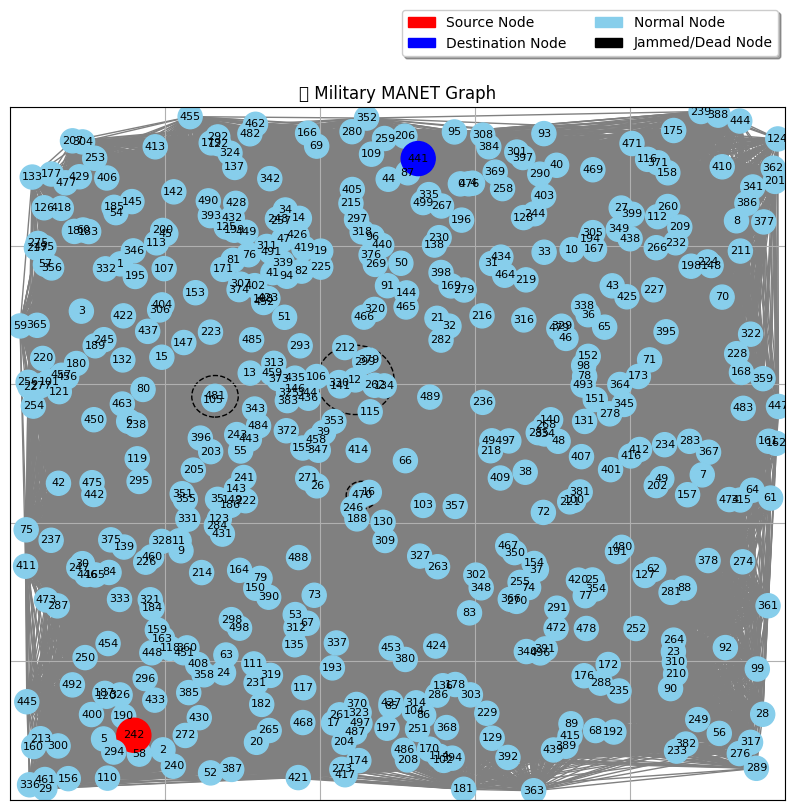

qiskit_runtime_service._discover_account:WARNING:2026-03-05 17:53:33,134: Loading account with the given token. A saved account will not be used.



!!! Running Pathfinding Algorithm for Optimal and Backup Paths at Step 7 !!!
[DEBUG] find_optimal_path_grover: Entered function (Hierarchical Grover).


qiskit_runtime_service.__init__:WARNING:2026-03-05 17:53:39,189: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-05 17:53:39,190: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-05 17:53:39,831: Using instance: open-instance, plan: open


[INFO] IBM Runtime initialized. Dual backend mode ready: ibm_fez + ibm_marrakesh
[DEBUG] Classical fallback: ENABLED
[DEBUG] Stage 0: Generating candidate paths with classical hard filtering...
[DEBUG: Reduction] Starting path generation for 500 nodes.
[DEBUG] Initial attempt: BEAM_WIDTH = 6. Found 240 paths.
[DEBUG] Final Beam Width (K): 6
[DEBUG] Generated 240 directional paths with beam width control, dynamic hop pruning, and shortest path refinement.
[DEBUG] Number of relaxation attempts performed: 0
[DEBUG: Cost Function] Path [242, 108, 166, 69, 440, 441] discarded due to link (242, 108) stability 0.02 below threshold 0.04.
[DEBUG: Cost Function] Path [242, 108, 69, 280, 441] discarded due to link (242, 108) stability 0.02 below threshold 0.04.
[DEBUG: Cost Function] Path [242, 108, 419, 69, 280, 441] discarded due to link (242, 108) stability 0.02 below threshold 0.04.
[DEBUG: Cost Function] Path [242, 108, 419, 441] discarded due to link (242, 108) stability 0.02 below threshol

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


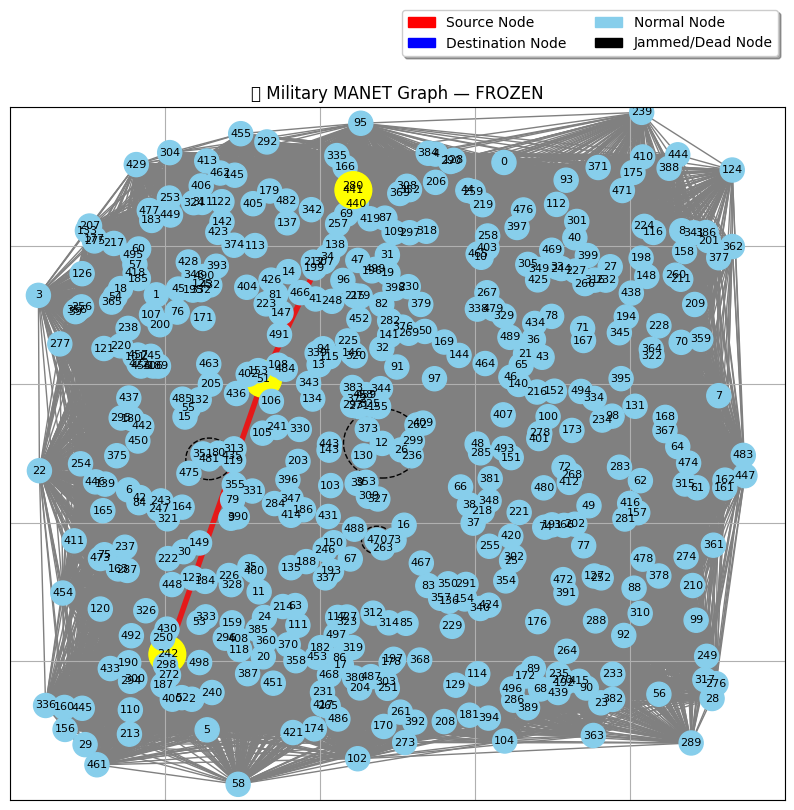


--- Displaying live status at Step 20 / 21 ---

--- Simulation Finished after 21 steps ---
Displaying frozen snapshot of optimal path.


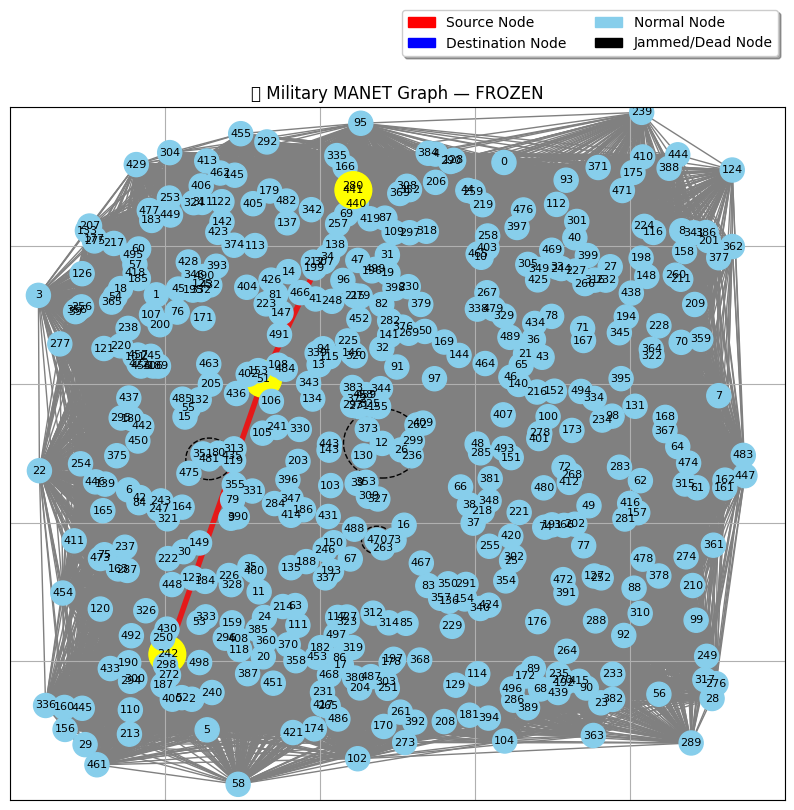


Packet Transmission Statistics
Total Packets Sent: 14
Total Packets Delivered: 14
Packet Delivery Rate (PDR): 100.00%
Average End-to-End Delay: 0.1200 seconds

Packet Drop Reasons Breakdown:

Throughput Statistics
Total Data Received: 7168 bytes
Simulation Duration: 21 seconds
Throughput: 2730.67 bps
Throughput: 2.73 Kbps
Throughput: 0.00 Mbps

Simulation Parameters
Number of Nodes: 500
Area Size: 100x100
Communication Range: 45
Destination Node ID: 441
Total Packets to Send: 25
Packet Size: 512 bytes
Packet Propagation Delay per Hop: 0.05

📊 MANET Performance Metrics (IEEE Style)
Packet Delivery Ratio (PDR): 1.0000
Packet Loss Ratio (PLR): 0.0000
Average End-to-End Delay: 0.1200 sec
Total Energy Consumed: 3651.73 units
Routing Overhead (Number of Candidate Paths): 160
Throughput: 2730.67 bits/sec
Primary Failures: 0
Backup Successes: 0
Recovery Rate (Backup Successes / Primary Failures): 0.0000
Quantum Classical Match Status: True
Stage 1 (Chunk Processing) Runtime: 214.7829 sec
Stag

In [ ]:
import copy
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import numpy as np
import pandas as pd
from datetime import datetime
import time
import importlib
import sys
import random

sys.path.insert(0, '.')

import mobility_simulator
import grover_router
import user_input
import jammer_config
import jammer_logic

from google.colab import userdata
ibm_token = userdata.get('bannu')


class Packet:
    def __init__(self, packet_id, source_node_id, dest_node_id, start_time):
        self.packet_id = packet_id
        self.source_node_id = source_node_id
        self.dest_node_id = dest_node_id
        self.start_time = start_time
        self.end_time = None
        self.delivered = False
        self.drop_reason = None
        self.path_taken = []
        self.attempt_type = "primary"

PACKET_PROPAGATION_DELAY_PER_HOP = 0.05
NODE_PROCESSING_DELAY = 0.01
RETRY_DELAY = 0.02
TOTAL_PACKETS = 25
PACKET_SIZE_BYTES = 512

DROP_REASON_INVALID_PATH = "INVALID_PATH"
DROP_REASON_NODE_UNREACHABLE = "NODE_UNREACHABLE"
DROP_REASON_JAMMED_NODE = "JAMMED_NODE"
DROP_REASON_LINK_BROKEN_DISTANCE = "LINK_BROKEN_DISTANCE"
DROP_REASON_LINK_JAMMED = "LINK_JAMMED"
importlib.reload(user_input)
importlib.reload(mobility_simulator)
importlib.reload(jammer_config)
importlib.reload(jammer_logic)
importlib.reload(grover_router)

width, height, num_nodes, steps, comm_range, source, DEST_ID, user_step = user_input.get_user_input()
AREA_SIZE = width
NUM_NODES = num_nodes
TIME_STEPS = steps
COMM_RANGE = comm_range

nodes = mobility_simulator.initialize_nodes(NUM_NODES, AREA_SIZE)
# ---------------- FIX 2 ----------------
for node in nodes:
    node.energy_initial = node.energy
# -------------------------------------
G_init = nx.Graph()
for node in nodes:
    G_init.add_node(node.id, pos=tuple(node.position))

jammers = jammer_config.init_jammers([node.position for node in nodes], G_init)
print("Jammers in this simulation: ", jammers)

frozen_snapshot = {
    "graph": None,
    "positions": None,
    "nodes": None,
    "jammers": None,
    "node_colors": None,
    "node_sizes": None,
    "edges": None,
    "highlight_nodes": None
}
current_positions = None
last_frame = 0
optimal_path_found = False

grover_oracle_paths_for_print = []
grover_oracle_breakdowns_for_print = []

def build_graph_from_nodes(nodes_list, jammers_list, frame):
    G = nx.Graph()
    for node_i in nodes_list:
        if getattr(node_i, "energy", 0) <= 0
            continue
        G.add_node(
            node_i.id,
            pos=tuple(node_i.position),
            trust=node_i.trust,
            energy=node_i.energy,
            jammed=node_i.jammed,
        )

    for i in range(len(nodes_list)):
        node_i = nodes_list[i]
        if getattr(node_i, "energy", 0) <= 0  or node_i.id not in G.nodes:
            continue
        for j in range(i + 1, NUM_NODES):
            node_j = nodes_list[j]
            if getattr(node_j, "energy", 0) <= 0 or node_j.id not in G.nodes:
                continue

            distance = np.linalg.norm(node_i.position - node_j.position)
            range_limit = COMM_RANGE

            if distance <= range_limit:
                effective_cost = distance
                link_stability = 1.0 - (distance / range_limit)
                link_stability = max(0.0, min(1.0, link_stability))
                G.add_edge(node_i.id, node_j.id, weight=effective_cost, stability=link_stability)

    positions = {n: tuple(G.nodes[n]["pos"]) for n in G.nodes}
    return G, positions

def default_node_colors_and_sizes(G):
    colors = []
    sizes = []
    node_list = list(G.nodes)
    for n in node_list:
        nd = G.nodes[n]
        if n == source:
            colors.append("red")
            sizes.append(600)
        elif n == DEST_ID:
            colors.append("blue")
            sizes.append(600)
        elif nd.get("jammed", False):
            colors.append("black")
            sizes.append(300)
        elif nd.get("trust", 1.0) < 0.6:
            colors.append("orange")
            sizes.append(300)
        else:
            colors.append("skyblue")
            sizes.append(300)
    return colors, sizes

def draw_graph(ax, G, positions, highlight_edges=None, highlight_nodes=None,
               node_colors=None, node_sizes=None, live_pulse_frame=None):
    ax.clear()
    ax.set_xlim(0, AREA_SIZE)
    ax.set_ylim(0, AREA_SIZE)
    ax.grid(True)
    title = "\U0001F4E1 Military MANET Graph"
    if frozen_snapshot["graph"] is not None:
        title += " — FROZEN"
    ax.set_title(title)

    node_colors_to_draw = []
    node_sizes_to_draw = []
    for n in G.nodes:
        if highlight_nodes and n in highlight_nodes:
            node_colors_to_draw.append('yellow')
            node_sizes_to_draw.append(700)
        elif n == source:
            node_colors_to_draw.append("red")
            node_sizes_to_draw.append(600)
        elif n == DEST_ID:
            node_colors_to_draw.append("blue")
            node_sizes_to_draw.append(600)
        elif G.nodes[n].get("jammed", False):
            node_colors_to_draw.append("black")
            node_sizes_to_draw.append(300)
        elif G.nodes[n].get("trust", 1.0) < 0.6:
            node_colors_to_draw.append("orange")
            node_sizes_to_draw.append(300)
        else:
            node_colors_to_draw.append("skyblue")
            node_sizes_to_draw.append(300)

    nx.draw_networkx_edges(G, positions, ax=ax, edge_color="gray", width=1.0)

    if highlight_edges:
        nx.draw_networkx_edges(G, positions, ax=ax, edgelist=highlight_edges,
                               edge_color='red', width=4.0, alpha=0.8)

    nx.draw_networkx_nodes(G, positions, ax=ax, nodelist=G.nodes,
                           node_color=node_colors_to_draw, node_size=node_sizes_to_draw)

    nx.draw_networkx_labels(G, positions, ax=ax, font_size=8)

    for jammer in jammers:
        if jammer.get('location') == 'node':
            tgt = jammer['target']
            if tgt in positions:
                x, y = positions[tgt]
                circle = patches.Circle((x, y), jammer['radius'], fill=False, edgecolor='black', linestyle='--', linewidth=1)
                ax.add_patch(circle)

    add_legend(ax)
    plt.show()

def add_legend(ax):
    legend_handles = [
        patches.Patch(color='red', label='Source Node'),
        patches.Patch(color='blue', label='Destination Node'),
        patches.Patch(color='skyblue', label='Normal Node'),
        patches.Patch(color='black', label='Jammed/Dead Node')
    ]
    ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.0, 1.15), fancybox=True, shadow=True, ncol=2)

def export_cost_breakdown_to_excel(candidate_paths, path_cost_breakdowns, optimal_path=None):
    if not candidate_paths or not path_cost_breakdowns:
        print("[UI] No path data available for Excel export.")
        return

    data = []
    columns = ["Path #", "Status", "Path Sequence", "Edge Costs", "Trust Penalties", "Energy Penalties",
               "Jam Penalties", "Hop Penalties", "Stability Penalties", "Reliability Penalties", "Medium Stability Penalty", "Total Cost"]

    for i, (path, breakdown) in enumerate(zip(candidate_paths, path_cost_breakdowns)):
        path_str = " \u2192 ".join(map(str, path))
        is_optimal = "\u2605 OPTIMAL" if optimal_path and path == optimal_path else ""
        row_data = {
            "Path #": i+1,
            "Status": is_optimal,
            "Path Sequence": path_str,
            "Edge Costs": round(breakdown.get('edge_costs', float('inf')), 2) if breakdown['total'] != float('inf') else float('inf'),
            "Trust Penalties": round(breakdown.get('trust_penalties', 0), 2) if breakdown['total'] != float('inf') else float('inf'),
            "Energy Penalties": round(breakdown.get('energy_penalties', 0), 2) if breakdown['total'] != float('inf') else float('inf'),
            "Jam Penalties": round(breakdown.get('jam_penalties', 0), 2) if breakdown['total'] != float('inf') else float('inf'),
            "Hop Penalties": round(breakdown.get('hop_penalties', 0), 2) if breakdown['total'] != float('inf') else float('inf'),
            "Stability Penalties": round(breakdown.get('stability_penalties', 0), 2) if breakdown['total'] != float('inf') else float('inf'), # New
            "Reliability Penalties": round(breakdown.get('reliability_penalties', 0), 2) if breakdown['total'] != float('inf') else float('inf'), # New
            "Medium Stability Penalty": round(breakdown.get('medium_stability_penalty', 0), 2) if breakdown['total'] != float('inf') else float('inf'), # New
            "Total Cost": round(breakdown['total'], 2) if breakdown['total'] != float('inf') else float('inf')
        }
        data.append(row_data)

    df = pd.DataFrame(data, columns=columns)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"candidate_paths_analysis_{timestamp}.xlsx"

    try:
        with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
            df.to_excel(writer, sheet_name='Path Analysis', index=False, startrow=4)
            workbook = writer.book
            worksheet = writer.sheets['Path Analysis']
            title_format = workbook.add_format({'bold': True, 'font_size': 14, 'align': 'center'})
            worksheet.merge_range('A1:L1', 'MANET Path Analysis Results', title_format)
            for i, col in enumerate(df.columns):
                max_len = max(df[col].astype(str).str.len().max(), len(col)) + 2
                worksheet.set_column(i, i, max_len)
        print(f"\n[UI] Successfully exported path analysis to '{filename}'.")
    except ImportError:
        csv_filename = filename.replace(".xlsx", ".csv")
        df.to_csv(csv_filename, index=False)
        print(f"[UI] Exported to CSV fallback: '{csv_filename}'.")
    except Exception as e:
        print(f"[ERROR] Failed to export Excel file: {e}")

def simulate_packet_transmission(packet, current_path, current_nodes, current_jammers, comm_range, frame_time):
    nodes_by_id = {n.id: n for n in current_nodes}
    current_delay = 0.0
    path_in_use = list(current_path)

    if not path_in_use or len(path_in_use) < 2:
        packet.drop_reason = DROP_REASON_INVALID_PATH
        packet.delivered = False
        return packet

    packet.path_taken.append(path_in_use[0])

    for i in range(len(path_in_use) - 1):
        node_u_id = path_in_use[i]
        node_v_id = path_in_use[i+1]

        if node_u_id not in nodes_by_id or node_v_id not in nodes_by_id:
            packet.drop_reason = DROP_REASON_NODE_UNREACHABLE
            packet.delivered = False
            return packet

        node_u = nodes_by_id[node_u_id]
        node_v = nodes_by_id[node_v_id]

        if node_u.energy <= 0 or node_v.energy <= 0:
            packet.drop_reason = DROP_REASON_NODE_DEAD
            packet.delivered = False
            return packet
        # if node_u.jammed or node_v.jammed:
        #     packet.drop_reason = DROP_REASON_JAMMED_NODE
        #     packet.delivered = False
        #     return packet

        distance = np.linalg.norm(node_u.position - node_v.position)
        current_range_limit = COMM_RANGE

        link_broken_distance = (distance > current_range_limit)
        link_jammed_by_logic = jammer_logic.is_node_blocked(node_u.id, node_v.id, current_jammers, frame_time)

        if link_broken_distance:
            packet.drop_reason = DROP_REASON_LINK_BROKEN_DISTANCE
            packet.delivered = False
            return packet
        if link_jammed_by_logic:
            packet.drop_reason = DROP_REASON_LINK_JAMMED
            packet.delivered = False
            return packet

        if not packet.path_taken or packet.path_taken[-1] != node_v.id:
            packet.path_taken.append(node_v.id)
        current_delay += PACKET_PROPAGATION_DELAY_PER_HOP
        current_delay += NODE_PROCESSING_DELAY

    packet.delivered = True
    packet.end_time = frame_time + current_delay
    return packet


def run_simulation():
    global nodes, current_positions, last_frame, optimal_path_found, jammers, all_candidate_paths_from_grover, all_breakdowns_from_grover, grover_oracle_paths_for_print, grover_oracle_breakdowns_for_print
    fig, ax = plt.subplots(figsize=(10, 9))

    total_candidate_paths_evaluated = 0

    packet_id_counter = 0
    packets_sent = []
    packets_delivered = []
    total_delay = 0.0

    primary_failures = 0
    backup_successes = 0

    drop_reasons_counter = {
        "INVALID_PATH": 0,
        "NODE_UNREACHABLE": 0,
        "NODE_DEAD": 0,
        "JAMMED_NODE": 0,
        "LINK_BROKEN_DISTANCE": 0,
        "LINK_JAMMED": 0,
    }
    current_primary_path = None
    all_candidate_paths_from_grover = []
    all_breakdowns_from_grover = []

    quantum_classical_match_status = False
    stage1_total_runtime = 0.0
    stage6_final_runtime = 0.0
    total_grover_search_runtime = 0.0


    for frame in range(TIME_STEPS):
        last_frame = frame
        mobility_simulator.move_nodes(nodes, comm_range=COMM_RANGE)
        G, positions = build_graph_from_nodes(nodes, jammers, frame)

        if source not in G.nodes or DEST_ID not in G.nodes:
            print(f"[SIMULATION WARNING] Source ({source}) or Destination ({DEST_ID}) node not in graph at frame {frame}. Skipping pathfinding.")
            optimal_path_found = False
            current_primary_path = None
        elif frame == user_step or (current_primary_path and not nx.has_path(G, source, DEST_ID)):
            if frame == user_step:
                print(f"\n!!! Running Pathfinding Algorithm for Optimal and Backup Paths at Step {frame} !!!")
            elif current_primary_path and not nx.has_path(G, source, DEST_ID):
                print(f"\n!!! Re-running Pathfinding Algorithm due to broken primary path at Step {frame} !!!")
            path_finding_start_time = time.time()

            try:
                dest_id_returned, primary_path, primary_edges, primary_cost_details, \
                backup_edges, backup_cost_details, \
                all_feasible_paths, all_feasible_breakdowns, \
                quantum_classical_match_status, stage1_total_runtime, stage6_final_runtime, total_grover_search_runtime = grover_router.find_optimal_path_grover(
                    G, nodes, source, DEST_ID, ibm_token=ibm_token
                )

                all_candidate_paths_from_grover = all_feasible_paths
                all_breakdowns_from_grover = all_feasible_breakdowns

                grover_oracle_paths_for_print = all_feasible_paths
                grover_oracle_breakdowns_for_print = all_feasible_breakdowns

                total_candidate_paths_evaluated = len(all_candidate_paths_from_grover)

                current_primary_path = primary_path

                print(f"[RESULT] Primary path found: {primary_path}")
                if primary_cost_details:
                    print(f"[RESULT] Total Primary Cost: {primary_cost_details['total']:.2f}")
                else:
                    print("[RESULT] Primary path cost details are None.")

                path_finding_end_time = time.time()
                path_finding_time = path_finding_end_time - path_finding_start_time
                print(f"[TIMING] Total Pathfinding Wall-Clock Time (including Grover): {path_finding_time:.4f} seconds")
                print(f"[TIMING] Stage 1 (Chunk Processing) Grover Runtime: {stage1_total_runtime:.4f} seconds")
                print(f"[TIMING] Stage 6 (Final Grover Stage) Runtime: {stage6_final_runtime:.4f} seconds")
                print(f"[TIMING] Total Quantum Grover Search Runtime: {total_grover_search_runtime:.4f} seconds")
                print(f"[DEBUG] Quantum result matched classical argmin: {quantum_classical_match_status}")

                export_cost_breakdown_to_excel(all_candidate_paths_from_grover, all_breakdowns_from_grover, optimal_path=primary_path)

                frozen_snapshot["graph"] = G
                frozen_snapshot["positions"] = positions
                frozen_snapshot["nodes"] = copy.deepcopy(nodes)
                frozen_snapshot["jammers"] = copy.deepcopy(jammers)
                frozen_snapshot["highlight_edges"] = primary_edges
                frozen_snapshot["highlight_nodes"] = primary_path

                optimal_path_found = True
                fig_snap, ax_snap = plt.subplots(figsize=(10, 9))
                draw_graph(ax_snap, G, positions, highlight_edges=primary_edges, highlight_nodes=primary_path)

            except RuntimeError as e:
                print(f"[SIMULATION ERROR] Could not find path: {e}")
                current_primary_path = None
                optimal_path_found = False
                fig_snap, ax_snap = plt.subplots(figsize=(10, 9))
                draw_graph(ax_snap, G, positions)

        if optimal_path_found and current_primary_path and len(packets_sent) < TOTAL_PACKETS:
            packet_id_counter += 1
            new_packet = Packet(packet_id_counter, source, DEST_ID, frame)
            packets_sent.append(new_packet)

            simulated_packet_primary = simulate_packet_transmission(
                copy.deepcopy(new_packet), current_primary_path, nodes, jammers, COMM_RANGE, frame
            )
            simulated_packet_primary.attempt_type = "primary"

            if simulated_packet_primary.delivered:
                packets_delivered.append(simulated_packet_primary)
                total_delay += (simulated_packet_primary.end_time - simulated_packet_primary.start_time)
            else:
                primary_failures += 1


        if frame % 20 == 0:
            if source in G.nodes and DEST_ID in G.nodes:
                print(f"\n--- Displaying live status at Step {frame} / {TIME_STEPS} ---")
                draw_graph(ax, G, positions)
            else:
                print(f"\n--- Skipping live graph display at Step {frame} as source/destination nodes are not in graph ---")
                ax.clear()
                ax.set_title("\U0001F4E1 Military MANET Graph - Nodes Not Connected")
                plt.show()

    print(f"\n--- Simulation Finished after {TIME_STEPS} steps ---")
    fig_final, ax_final = plt.subplots(figsize=(10, 9))
    if frozen_snapshot["graph"] is not None:
        print("Displaying frozen snapshot of optimal path.")
        draw_graph(ax_final, frozen_snapshot["graph"], frozen_snapshot["positions"],
                   highlight_edges=frozen_snapshot.get('highlight_edges') if frozen_snapshot.get('highlight_edges') else None,
                   highlight_nodes=frozen_snapshot.get('highlight_nodes') if frozen_snapshot.get('highlight_nodes') else None)
    else:
        print("No optimal path found/frozen. Displaying final live network state.")
        if source in G.nodes and DEST_ID in G.nodes:
            draw_graph(ax_final, G, positions, highlight_edges=frozen_snapshot.get('highlight_edges') if frozen_snapshot.get('highlight_edges') else None,
                       highlight_nodes=frozen_snapshot.get('highlight_nodes') if frozen_snapshot.get('highlight_nodes') else None)
        else:
            print("Cannot display final live network state: source or destination nodes not in graph.")


    print("\n" + "="*40)
    print("Packet Transmission Statistics")
    print("="*40)
    print(f"Total Packets Sent: {len(packets_sent)}")
    print(f"Total Packets Delivered: {len(packets_delivered)}")

    pdr = (len(packets_delivered) / len(packets_sent)) if packets_sent else 0
    print(f"Packet Delivery Rate (PDR): {pdr*100:.2f}%")

    avg_e2e_delay = total_delay / len(packets_delivered) if packets_delivered else 0
    print(f"Average End-to-End Delay: {avg_e2e_delay:.4f} seconds")

    print("\nPacket Drop Reasons Breakdown:")
    for reason, count in drop_reasons_counter.items():
        if count > 0:
            print(f"  - {reason}: {count}")
    print("="*40)

    total_data_received_bytes = len(packets_delivered) * PACKET_SIZE_BYTES
    total_data_received_bits = total_data_received_bytes * 8
    simulation_duration_seconds = TIME_STEPS

    throughput_bps = 0.0
    if simulation_duration_seconds > 0:
        throughput_bps = total_data_received_bits / simulation_duration_seconds

    throughput_kbps = throughput_bps / 1000
    throughput_mbps = throughput_kbps / 1000

    print("\n" + "="*40)
    print("Throughput Statistics")
    print("="*40)
    print(f"Total Data Received: {total_data_received_bytes} bytes")
    print(f"Simulation Duration: {simulation_duration_seconds} seconds")
    print(f"Throughput: {throughput_bps:.2f} bps")
    print(f"Throughput: {throughput_kbps:.2f} Kbps")
    print(f"Throughput: {throughput_mbps:.2f} Mbps")
    print("="*40)

    print("\n" + "="*40)
    print("Simulation Parameters")
    print("="*40)
    print(f"Number of Nodes: {NUM_NODES}")
    print(f"Area Size: {AREA_SIZE}x{AREA_SIZE}")
    print(f"Communication Range: {COMM_RANGE}")
    print(f"Destination Node ID: {DEST_ID}")
    print(f"Total Packets to Send: {TOTAL_PACKETS}")
    print(f"Packet Size: {PACKET_SIZE_BYTES} bytes")
    print("="*40)
    print(f"Packet Propagation Delay per Hop: {PACKET_PROPAGATION_DELAY_PER_HOP}")


    total_packets_dropped = len(packets_sent) - len(packets_delivered)

    avg_e2e_delay_for_delivered = total_delay/len(packets_delivered) if len(packets_delivered) > 0 else 0

    total_energy_initial = sum(getattr(node, "energy_initial", 85.0) for node in nodes)
    total_energy_final = sum(getattr(node, "energy", 70.0) for node in nodes)
    energy_consumed = total_energy_initial - total_energy_final

    routing_overhead = total_candidate_paths_evaluated

    PLR = total_packets_dropped / len(packets_sent) if len(packets_sent) > 0 else 0

    total_data_received_bits_for_metrics = len(packets_delivered) * PACKET_SIZE_BYTES * 8
    simulation_duration_seconds = TIME_STEPS
    throughput_bps_for_metrics = total_data_received_bits_for_metrics / simulation_duration_seconds if simulation_duration_seconds > 0 else 0

    recovery_rate = backup_successes / primary_failures if primary_failures > 0 else 0

    print("\n" + "="*50)
    print("\U0001F4CA MANET Performance Metrics (IEEE Style)")
    print("="*50)
    print(f"Packet Delivery Ratio (PDR): {pdr:.4f}")
    print(f"Packet Loss Ratio (PLR): {PLR:.4f}")
    print(f"Average End-to-End Delay: {avg_e2e_delay_for_delivered:.4f} sec")
    print(f"Total Energy Consumed: {energy_consumed:.2f} units")
    print(f"Routing Overhead (Number of Candidate Paths): {routing_overhead}")
    print(f"Throughput: {throughput_bps_for_metrics:.2f} bits/sec")
    print(f"Primary Failures: {primary_failures}")
    print(f"Backup Successes: {backup_successes}")
    print(f"Recovery Rate (Backup Successes / Primary Failures): {recovery_rate:.4f}")
    print(f"Quantum Classical Match Status: {quantum_classical_match_status}")
    print(f"Stage 1 (Chunk Processing) Runtime: {stage1_total_runtime:.4f} sec")
    print(f"Stage 2 (Final Grover) Runtime: {stage6_final_runtime:.4f} sec")
    print(f"Total Grover Search Runtime: {total_grover_search_runtime:.4f} sec")
    print("="*50)

    return packets_sent, packets_delivered, total_delay, drop_reasons_counter, throughput_bps, avg_e2e_delay

if __name__ == "__main__":
    global_packets_sent, global_packets_delivered, global_total_delay, global_drop_reasons_counter, global_throughput_bps, global_avg_e2e_delay = run_simulation()

    if optimal_path_found and frozen_snapshot["graph"] is not None and frozen_snapshot["nodes"] is not None:
        if 'grover_oracle_paths_for_print' in globals() and grover_oracle_paths_for_print:
            optimal_path_from_snapshot = frozen_snapshot["highlight_nodes"]

            print("[UI] Cost breakdown printing to console removed. Please check the Excel export for details.")
        else:
            print("[UI] No paths sent to Grover Oracle available to print cost breakdown.")
    else:
        print("[UI] No optimal path found or frozen snapshot data available to print cost breakdown.")
